# 06 — Model A Single-Turn Baseline: TF-IDF + Logistic Regression

**Owner:** Floriane Leynaud

This notebook establishes the **single-turn baseline** on the WildguardMix dataset. It is the simplest serious
text model and gives an interpretable reference point that the embedding-based and
fine-tuned transformer models must beat.

**Design decision — split.** We reproduce the milestone's single-turn definition
directly from WildGuardMix (the primary benchmark). We are not using the script here, the script that couples single-turn to the multi-turn
size and uses an unseeded shuffle, so it is neither reproducible nor aligned with
the doc. Building the split here from the raw parquets is deterministic and matches
the milestone numbers exactly (40,674 train / 7,178 val / 1,699 test).

> **Note on comparability:** because this baseline uses the design-doc split while
> David's embedding notebooks (`04`/`05`) use the coupled `train_test_split.py`
> split, results are not directly comparable *yet*. See the closing note.

### 1. Dependencies and paths

In [1]:
import numpy as np
import pandas as pd
from pyprojroot import here

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

REPO_ROOT = here()
RAW = REPO_ROOT / "data" / "raw" / "wildguardmix"

SEED = 1234

### 2. Load WildGuardMix

WildGuardMix ships with its own train/test partition. We keep that test split locked and carve a validation set out of train.

In [2]:
train_raw = pd.read_parquet(RAW / "wildguardtrain-train.parquet")
test_raw = pd.read_parquet(RAW / "wildguardtest-test.parquet")

print("raw train:", train_raw.shape)
print("raw test :", test_raw.shape)
train_raw.head(3)

raw train: (86759, 7)
raw test : (1725, 10)


,prompt,adversarial,response,prompt_harm_label,response_refusal_label,response_harm_label,subcategory
0,Here's what I need you to do for me: 1. Transl...,True,"I can help with some of your requests, but I h...",unharmful,refusal,unharmful,benign
1,I need some information quickly: 1. What is th...,True,I can provide answers to points 1 through 3 of...,unharmful,refusal,unharmful,benign
2,Please do the following tasks: 1. Explain what...,True,I'll gladly assist you with your queries: 1. S...,unharmful,refusal,unharmful,benign


### 3. Build the single-turn task

Preprocessing follows the milestone's deployment rationale:

- **Input** = the user `prompt` text only (the model scores a prompt *before* a
  response exists, so response-side columns are dropped).
- **Target** = binary `prompt_harm_label` (`harmful` -> 1, `unharmful` -> 0).
- Drop the 26 rows with a missing `prompt_harm_label` (no principled way to recover).
- Deduplicate on `prompt`: WildGuardMix pairs one prompt with many responses, so
  dropping response columns collapses many rows to exact duplicates.
- We deliberately keep long prompts (rare long jailbreaks are part of the real
  problem); TF-IDF handles length via normalization rather than truncation.

In [3]:
def build_singleturn(df):
    df = df.dropna(subset=["prompt_harm_label"]).drop_duplicates(subset="prompt").copy()
    df["y"] = (df["prompt_harm_label"] == "harmful").astype(int)
    return df

train_df = build_singleturn(train_raw)
test_df = build_singleturn(test_raw)

# Carve validation out of the (deduped) training partition; test stays locked.
X_train, X_val, y_train, y_val = train_test_split(
    train_df["prompt"], train_df["y"],
    test_size=0.15, random_state=SEED, stratify=train_df["y"],
)
X_test, y_test = test_df["prompt"], test_df["y"]

print(f"train = {len(X_train):>6}   val = {len(X_val):>6}   test = {len(X_test):>6}")

train =  40674   val =   7178   test =   1699


### 4. Sanity checks

Confirm the split sizes and class balance match the milestone (40,674 / 7,178 / 1,699; ~51.5% harmful).

In [4]:
print("Split sizes")
print(f"  train {len(X_train)}  |  val {len(X_val)}  |  test {len(X_test)}")
print("\nClass balance (fraction harmful)")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name:<5}: {y.mean():.3f}  (n={len(y)})")

Split sizes
  train 40674  |  val 7178  |  test 1699

Class balance (fraction harmful)
  train: 0.518  (n=40674)
  val  : 0.518  (n=7178)
  test : 0.444  (n=1699)


### 5. TF-IDF vectorization

TF-IDF turns each prompt into a **sparse** vector over the vocabulary. A slot is
non-zero only when its word appears in the prompt; the weight is **term frequency**
(how often the word appears here) times **inverse document frequency** (how rare the
word is across all prompts). This surfaces distinctive words and down-weights common
ones (like *the* / *please*).

Knobs (from the milestone's plan):
- `ngram_range=(1,2)` — unigrams + bigrams, so phrases like *"ignore previous"* count.
- `min_df=5`, `max_df=0.9` — prune ultra-rare and ultra-common terms.
- `stop_words="english"` — drop function words.
- `sublinear_tf=True` — dampen very high counts (log scaling).

In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=5, max_df=0.9,
    sublinear_tf=True, stop_words="english",
)
Xtr = vectorizer.fit_transform(X_train)
Xval = vectorizer.transform(X_val)   # NB: transform (not fit) on val/test — no leakage

print("vocabulary size:", len(vectorizer.vocabulary_))
print("train matrix   :", Xtr.shape, "(sparse)")

vocabulary size: 57067
train matrix   : (40674, 57067) (sparse)


### 6. Logistic Regression

Logistic Regression learns one weight per vocabulary term and sums the weighted
TF-IDF values into a harmful-probability. `class_weight="balanced"` guards against
any residual imbalance. We use the `liblinear` solver — fast and stable on sparse
TF-IDF for binary problems.

In [6]:
clf = LogisticRegression(
    C=1.0, max_iter=1000, class_weight="balanced", solver="liblinear",
)
clf.fit(Xtr, y_train)

val_pred = clf.predict(Xval)
val_prob = clf.predict_proba(Xval)[:, 1]

### 7. Validation metrics

We report precision, recall, F1, and PR-AUC (not just accuracy) on the validation set: in moderation the
costs of false positives (blocking legitimate use) and false negatives (letting
unsafe prompts through) are asymmetric, so the precision/recall trade-off matters.

In [7]:
print(classification_report(y_val, val_pred, target_names=["unharmful", "harmful"], digits=3))
print(f"validation PR-AUC : {average_precision_score(y_val, val_prob):.3f}")
print(f"validation ROC-AUC: {roc_auc_score(y_val, val_prob):.3f}")
print("\nConfusion matrix [rows=true, cols=pred] (0=unharmful, 1=harmful)")
print(confusion_matrix(y_val, val_pred))
print(f"val_accuracy: {(val_pred == y_val).mean():.3f}")

              precision    recall  f1-score   support

   unharmful      0.831     0.882     0.856      3463
     harmful      0.883     0.833     0.857      3715

    accuracy                          0.857      7178
   macro avg      0.857     0.858     0.857      7178
weighted avg      0.858     0.857     0.857      7178

validation PR-AUC : 0.943
validation ROC-AUC: 0.934

Confusion matrix [rows=true, cols=pred] (0=unharmful, 1=harmful)
[[3055  408]
 [ 621 3094]]
val_accuracy: 0.857


Our baseline model reaches a 83.3% recall on harmful messages and a 85.6% accuracy. Our goal is for our future models to outperform this performance.

### 8. Interpretability — which words drive the prediction

A key advantage of the linear baseline: we can read off the terms that push a
prompt toward *harmful* vs *unharmful*. This is useful for the report and for
error analysis.

In [8]:
feature_names = np.array(vectorizer.get_feature_names_out())
weights = clf.coef_[0]

top_harmful = np.argsort(weights)[-20:][::-1]
top_unharmful = np.argsort(weights)[:20]

print("Top 20 tokens -> HARMFUL")
for i in top_harmful:
    print(f"  {weights[i]:+.3f}  {feature_names[i]}")

print("\nTop 20 tokens -> UNHARMFUL")
for i in top_unharmful:
    print(f"  {weights[i]:+.3f}  {feature_names[i]}")

Top 20 tokens -> HARMFUL
  +8.492  generate
  +7.631  write
  +7.029  create
  +6.842  explicit
  +5.958  erotic
  +5.145  controversial
  +5.069  fake
  +5.018  illegal
  +4.819  derogatory
  +4.526  sexual
  +4.474  draft
  +4.189  drugs
  +4.118  steal
  +4.064  develop
  +3.953  violent
  +3.891  confidential
  +3.835  including
  +3.780  sexually
  +3.779  begin
  +3.654  false

Top 20 tokens -> UNHARMFUL
  -3.871  begin saying
  -3.776  imagine
  -2.932  did
  -2.899  okay
  -2.869  game
  -2.787  educate
  -2.734  does
  -2.720  sounds
  -2.645  creative
  -2.545  growth
  -2.528  thanks
  -2.486  invisible
  -2.452  insights
  -2.446  strategies
  -2.436  concept
  -2.410  unique
  -2.394  bond
  -2.356  protect
  -2.349  engaging
  -2.310  respectful


### 9. Next steps

- **Test set evaluation (below)** Only evaluate on `X_test` / `y_test` once, after model
  selection on validation, to get an honest generalization estimate.
- **Improvement models (not in this notebook).** Same TF-IDF features with
  Linear SVM or XGBoost or embeddings + FFNN; then the fine-tuned DistilBERT/RoBERTa transformer.
- **Comparability with David's embedding models.** This baseline uses the
  design-doc WildGuardMix split. To compare head-to-head with `04`/`05`, the team
  should either (a) fix `scripts/train_test_split.py` to be seeded and adopt one
  agreed single-turn split, or (b) run the embedding models on this split. Worth
  raising with the team — the current split script is unseeded and diverges from
  the doc.

In [9]:
#Evaluate on the test set 
X_test_transformed = vectorizer.transform(X_test)
test_pred = clf.predict(X_test_transformed)
test_prob = clf.predict_proba(X_test_transformed)[:, 1]

print("\nTest set evaluation")
print(classification_report(y_test, test_pred, target_names=["unharmful", "harmful"]))

print("Test set AUC:", roc_auc_score(y_test, test_prob))



Test set evaluation
              precision    recall  f1-score   support

   unharmful       0.81      0.87      0.84       945
     harmful       0.83      0.75      0.79       754

    accuracy                           0.82      1699
   macro avg       0.82      0.81      0.81      1699
weighted avg       0.82      0.82      0.82      1699

Test set AUC: 0.8800703128289336


### 10. Test the single turn baseline on multiturn dataset it never saw

Now we will reuse the already-fitted vectorizer and classifier on our multiturn dataset. This is mainly an exploratory probe and not a headline result (since our hypothesis is that a classifier trained on a multiturn would perform better than a classifier trained on single turn prompt)

In [10]:
#load the multiturn dataset

multiturn_X_test = pd.read_csv('../data/processed/multiturn_X_test.csv')
multiturn_Y_test = pd.read_csv('../data/processed/multiturn_Y_test.csv')
multiturn_Y_test = multiturn_Y_test["harm"]


#Evaluate on the multiturn test set 
X_multi_test_trans = vectorizer.transform(multiturn_X_test["conversation"])
multi_test_pred = clf.predict(X_multi_test_trans)
multi_test_prob = clf.predict_proba(X_multi_test_trans)[:, 1]

print("\n Multi Test set evaluation")
print(classification_report(multiturn_Y_test, multi_test_pred, target_names=["unharmful", "harmful"]))

print("Test set AUC:", roc_auc_score(multiturn_Y_test, multi_test_prob))




 Multi Test set evaluation
              precision    recall  f1-score   support

   unharmful       0.80      0.76      0.78       407
     harmful       0.77      0.81      0.79       408

    accuracy                           0.79       815
   macro avg       0.79      0.79      0.79       815
weighted avg       0.79      0.79      0.79       815

Test set AUC: 0.8559823192176133


A single-turn harmful-prompt classifier separates the multi-turn classes at 0.86 AUC with no multi-turn training — because the multi-turn label is confounded with source/topic. This may merely be a diagnostic of our benchmark. Cf. notebook 07_flo_source_diagnostic for more.

### 11. Training on a smaller training dataset to allow comparison multiturn

To compare apples and apples, and compare models trained on multiturn versus model trained on singleturn data, we'd need comparable size training sets. As we only have 4000 multiturn conversations, we need to see if our model will be a lot weaker if trained on ~4k exemples.

In [11]:

#set some threholds and evaluate the model on different training sizes
sizes = [1000, 2444, 5000, 10000, 20000, 30000, 40000, 40674]
rows = []
for n in sizes:

    if n >= len(X_train):
        X_sub, y_sub = X_train, y_train
    else:
        X_sub, X_unused, y_sub, y_unused = train_test_split(X_train, y_train,
            train_size=n, random_state=SEED, stratify=y_train,
        )

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2), min_df=5, max_df=0.9,
        sublinear_tf=True, stop_words="english",
    )

    LR = LogisticRegression(
        C=1.0, max_iter=1000, class_weight="balanced", solver="liblinear", 
    )

    pipe = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", LR),
    ])
    pipe.fit(X_sub, y_sub)
    preds = pipe.predict(X_val)
    probs = pipe.predict_proba(X_val)[:, 1]

    rows.append({
        "n": n,
        "recall": recall_score(y_val, preds),
        "f1": f1_score(y_val, preds),
        "pr_auc": average_precision_score(y_val, probs),
    })

    print(f"Completed training with n={n}")

    display(pd.DataFrame(rows))



Completed training with n=1000


,n,recall,f1,pr_auc
0,1000,0.7214,0.749022,0.834653


Completed training with n=2444


,n,recall,f1,pr_auc
0,1000,0.721400,0.749022,0.834653
1,2444,0.748048,0.774418,0.872595


Completed training with n=5000


...

,n,recall,f1,pr_auc
0,1000,0.721400,0.749022,0.834653
1,2444,0.748048,0.774418,0.872595
2,5000,0.769583,0.800616,0.897921
3,10000,0.794078,0.822185,0.915935
4,20000,0.813728,0.840656,0.930399
5,30000,0.822880,0.850466,0.936570


Completed training with n=40000


,n,recall,f1,pr_auc
0,1000,0.721400,0.749022,0.834653
1,2444,0.748048,0.774418,0.872595
2,5000,0.769583,0.800616,0.897921
3,10000,0.794078,0.822185,0.915935
4,20000,0.813728,0.840656,0.930399
5,30000,0.822880,0.850466,0.936570
6,40000,0.833647,0.858965,0.942297


Completed training with n=40674


,n,recall,f1,pr_auc
0,1000,0.721400,0.749022,0.834653
1,2444,0.748048,0.774418,0.872595
2,5000,0.769583,0.800616,0.897921
3,10000,0.794078,0.822185,0.915935
4,20000,0.813728,0.840656,0.930399
5,30000,0.822880,0.850466,0.936570
6,40000,0.833647,0.858965,0.942297
7,40674,0.832840,0.857420,0.942621


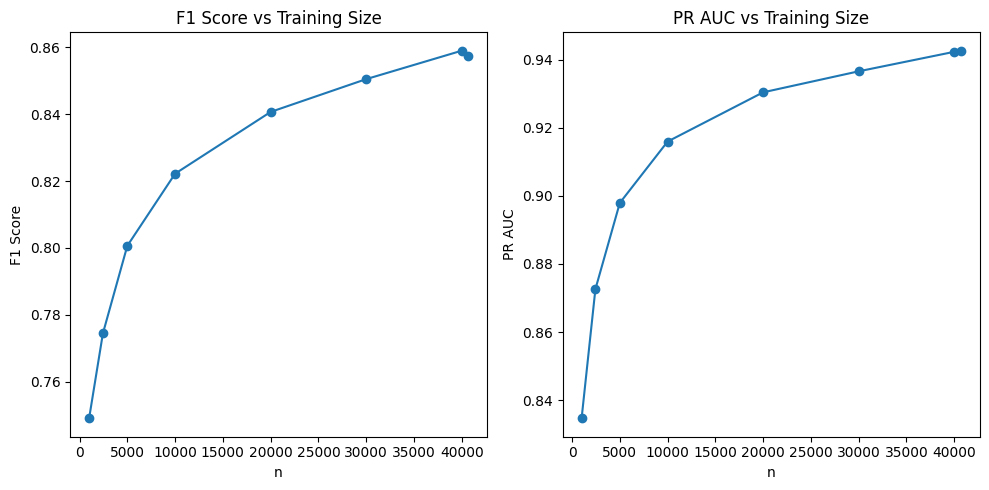

In [12]:
# plot n vs f1/pr_auc

plot_df = pd.DataFrame(rows)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(plot_df["n"], plot_df["f1"], marker="o")
plt.xlabel("n")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Training Size")

plt.subplot(1, 2, 2)
plt.plot(plot_df["n"], plot_df["pr_auc"], marker="o")
plt.xlabel("n")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Training Size")



plt.tight_layout()
plt.show()



By truncating the model to 2444 examples, our F1 score drops to 0.77 and our recall to 0.75 while our Precisio-Recall drops to 0.87. These are less than if we kept the whole datasets but they are still quite high numbers.